# Exploratory Analysis

This is a term that's used to describe a general process of getting to know a dataset from scratch. It's not a specific process, but more a collection of ideas and strategies that someone can use to start a data analysis process. It's meant to be the way you get a general picture of what's in your data so that you can decide what areas are worth following up on, and what is missing.

For our purposes, here's how we're defining exploratory analysis:

1. Know where your data comes from

2. Know how your data is structured

3. Get some basic statistics

<hr>

## Know where your data comes from

At this point, you should have a dataset you'd like to explore. Respond to the questions in the first part of your Week 7 Journal in Blackboard - you will likely need to search online for some answers!

## Know how it's structured

First, look at the data dictionary. What kind of features/columns are there? Are they structured as numerical data, categorical data, or something else? Why did the dataset builders collect the data they did? Did they leave out any type of data that could be important?


You have looked for missing data before (Climate Data Part 1). As for looking at the number of columns and rows, you can use the `df.shape` call, and also `head()` to see just columns. You can also see how many unique values there are in a column by making a call to `df['column_name'].value_counts()`. Here's a cheat sheet of Pandas calls you can use to look at your data: https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf.

Use the code block below to print out some statistics on the shape of your data. Don't forget to: 1) add your file to the notebook, 2) import pandas, and 3) read your csv into a dataframe first!

In [1]:
# Import pandas and load the dataset.
import pandas as pd
import numpy as np

df = pd.read_csv('Churn_Modelling.csv')

# 1. Shape — how many rows and columns?
print('Shape:', df.shape)
print(f'  -> {df.shape[0]:,} rows (customers) and {df.shape[1]} columns (features)')

# 2. First few rows — what do values look like?
print('\nFirst 3 rows:')
display(df.head(3))

# 3. Column names and data types — what kind of data is in each column?
print('Column data types:')
print(df.dtypes)

# 4. Missing data check — same step we used in the Climate Data project.
print('\nMissing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')

# 5. Unique-value counts for the categorical columns.
print('\nUnique values per column:')
for col in df.columns:
    n = df[col].nunique()
    print(f'  {col:20s}  {n:>6,} unique')

# Responsible-data-science note:
# The dataset includes RowNumber, CustomerId, and Surname. These are
# identifiers, not features — they should be excluded from any modeling we
# do, because (a) they have no predictive value and (b) Surname is
# personally identifying information. We'll drop them in the analysis
# dataframe below. The original df is kept intact so we can refer back to it.
df_analysis = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print(f'\nAnalysis dataframe (IDs dropped): {df_analysis.shape}')

Shape: (10000, 14)
  -> 10,000 rows (customers) and 14 columns (features)

First 3 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


Column data types:
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Total missing cells: 0

Unique values per column:
  RowNumber             10,000 unique
  CustomerId            10,000 unique
  Surname                2,932 unique
  CreditScore              460 unique
  Geography                  3 unique
  Gender     


After you've finished, answer the questions in the second part of your Week 7 Journal.

## Get some basic statistics

This is the last part of our exploratory analysis, and it's a bit more open ended. There are a lot of different ways you can get some basic statistics on your dataset, depending on whether you are looking at numerical data, or categorical data. For both, see some of the useful functions below. You can also check out some other functions in the cheat sheet https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf.

For numerical data, remember that one thing you can do is create a correlation matrix - this will give a high level overview of relationships between columns. Remember that you already used this technique in Climate Data Part 1 - you can use that as a reference.  

In [2]:
# Numerical Data

# Means of every numerical column.
print('Means of numerical columns:')
print(df_analysis.select_dtypes(include="number").mean().round(2))

# describe() bundles count, mean, std, min, quartiles, max in one table.
# This is more useful than calling mean/median/std individually because
# it shows the spread alongside the center.
print('\nNumerical summary (describe):')
display(df_analysis.describe().round(2))

# Correlation matrix — same technique as Climate Data Part 1.
# Sort by correlation with the target variable (Exited) to surface what
# might predict customer churn.
correlation_matrix = df_analysis.select_dtypes(include="number").corr()
print('\nCorrelations with Exited (1 = customer left, 0 = stayed):')
print(correlation_matrix['Exited'].sort_values(ascending=False).round(3))

# Categorical Data
print('\nCategorical column summary:')
display(df_analysis.describe(include=['object']))

# value_counts() for each categorical column — what are the categories
# and how common is each one?
for col in df_analysis.select_dtypes(include='object').columns:
    print(f'\nValue counts for {col}:')
    print(df_analysis[col].value_counts())

# A custom view that the standard methods don't give us:
# churn rate broken down by the categorical columns. This is where
# responsible-data-science attention pays off — group-level differences
# in the target variable can reveal disparate impact concerns that
# affect any model we build later.
print('\nChurn rate by Geography:')
print(df_analysis.groupby('Geography')['Exited'].agg(['mean','count']).round(3))

print('\nChurn rate by Gender:')
print(df_analysis.groupby('Gender')['Exited'].agg(['mean','count']).round(3))

Means of numerical columns:
CreditScore           650.53
Age                    38.92
Tenure                  5.01
Balance             76485.89
NumOfProducts           1.53
HasCrCard               0.71
IsActiveMember          0.52
EstimatedSalary    100090.24
Exited                  0.20
dtype: float64

Numerical summary (describe):


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0



Correlations with Exited (1 = customer left, 0 = stayed):
Exited             1.000
Age                0.285
Balance            0.119
EstimatedSalary    0.012
HasCrCard         -0.007
Tenure            -0.014
CreditScore       -0.027
NumOfProducts     -0.048
IsActiveMember    -0.156
Name: Exited, dtype: float64

Categorical column summary:


/tmp/ipykernel_545/1165480144.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_analysis.describe(include=['object']))


,Geography,Gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457



Value counts for Geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Value counts for Gender:
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Churn rate by Geography:
            mean  count
Geography              
France     0.162   5014
Germany    0.324   2509
Spain      0.167   2477

Churn rate by Gender:
         mean  count
Gender              
Female  0.251   4543
Male    0.165   5457


/tmp/ipykernel_545/1165480144.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_analysis.select_dtypes(include='object').columns:


Once you have some basic statistics, answer the questions in part 3 of your week 7 journal.

## Visualization

After getting some basic statistics, it's time to see how visualizing the data might give you some additional insights. Import matplotlib as you have done in both the college data and climate data projects, and use it to look at your data in a new way.

In [3]:
# Import matplotlib (and seaborn for nicer defaults).
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

/tmp/ipykernel_545/3383537893.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Retained (Exited=0)', 'Churned (Exited=1)'])


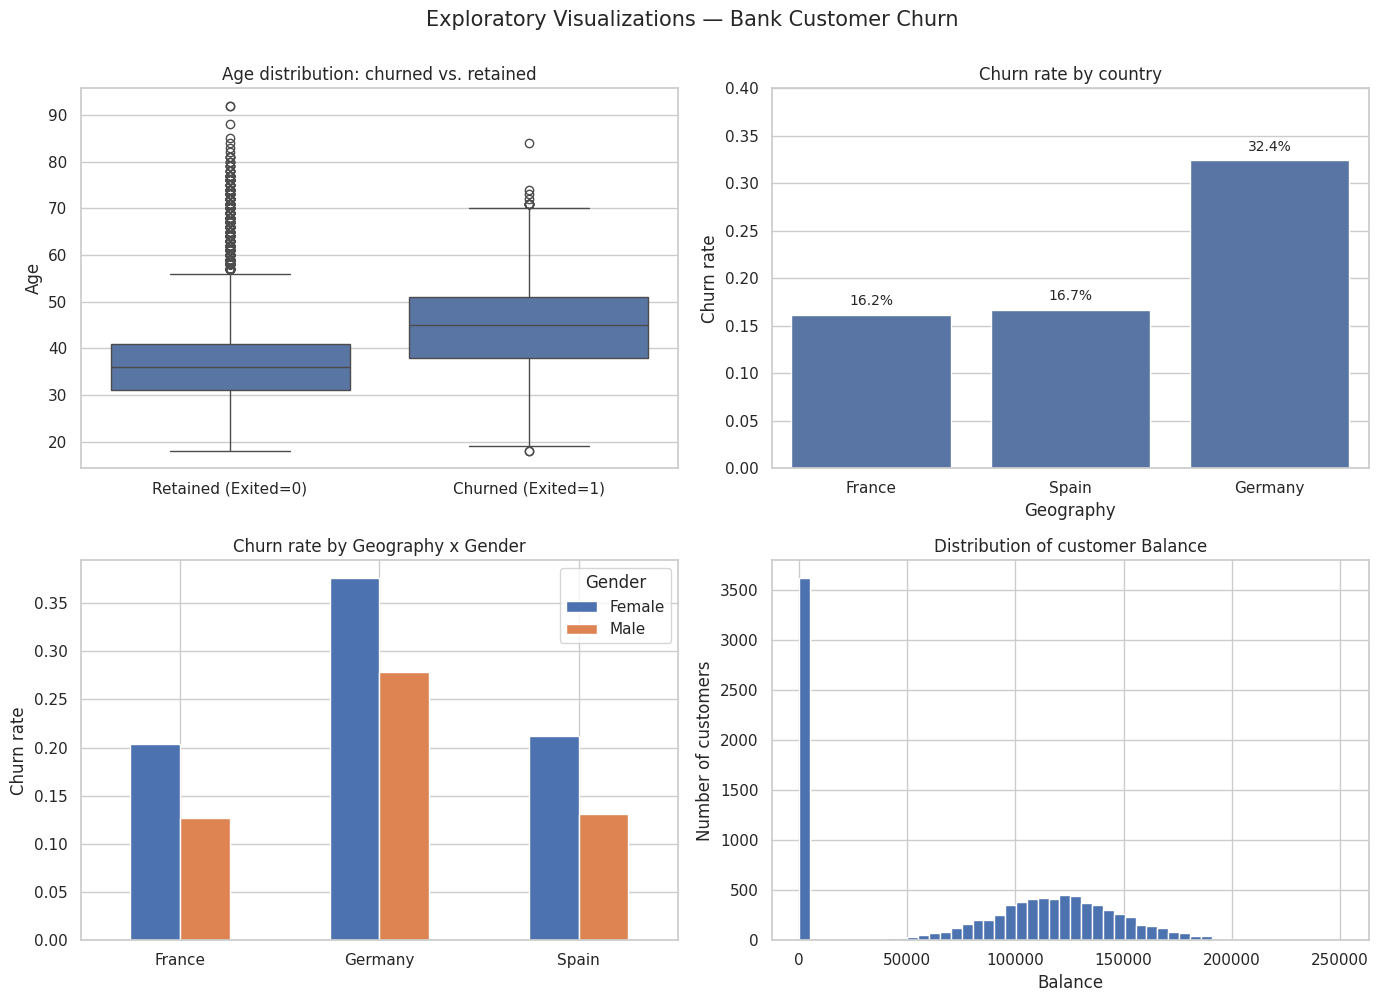

In [4]:
# I'll make four visualizations, each motivated by something I noticed in
# the basic statistics above. Each visualization answers a specific question.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Visualizations — Bank Customer Churn', fontsize=15, y=1.00)

# (1) Age has the strongest correlation with churn (r ~ 0.29). What does
# that look like? A box plot of Age split by Exited shows the difference
# in distributions, not just the difference in means.
sns.boxplot(data=df_analysis, x='Exited', y='Age', ax=axes[0, 0])
axes[0, 0].set_title('Age distribution: churned vs. retained')
axes[0, 0].set_xticklabels(['Retained (Exited=0)', 'Churned (Exited=1)'])
axes[0, 0].set_xlabel('')

# (2) The Geography churn-rate breakdown showed Germany churning almost
# twice as often as France or Spain. A bar chart makes this visible.
geo_churn = df_analysis.groupby('Geography')['Exited'].mean().sort_values()
sns.barplot(x=geo_churn.index, y=geo_churn.values, ax=axes[0, 1])
axes[0, 1].set_title('Churn rate by country')
axes[0, 1].set_ylabel('Churn rate')
axes[0, 1].set_ylim(0, 0.4)
for i, v in enumerate(geo_churn.values):
    axes[0, 1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

# (3) Female customers churned at 25.1% vs Male 16.5%. Cross with Geography
# to see whether the gender gap is consistent across countries — a country-
# specific disparity tells a different story than a uniform one.
gender_geo = df_analysis.groupby(['Geography','Gender'])['Exited'].mean().unstack()
gender_geo.plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Churn rate by Geography x Gender')
axes[1, 0].set_ylabel('Churn rate')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend(title='Gender')

# (4) Balance is a heavily-skewed numeric column (a lot of zeros). A
# histogram is the right tool to see the shape, including whether the
# zero-balance customers are a distinct sub-population.
axes[1, 1].hist(df_analysis['Balance'], bins=50, edgecolor='white')
axes[1, 1].set_title('Distribution of customer Balance')
axes[1, 1].set_xlabel('Balance')
axes[1, 1].set_ylabel('Number of customers')

plt.tight_layout()
plt.show()

# What I learn from these four plots:
# - Older customers churn more, and the median age of churners is clearly
#   higher than the median age of those who stay (~45 vs ~36).
# - Germany has a markedly higher churn rate. This is worth flagging:
#   any model trained on this data will pick that up, and we should be
#   careful about whether the model is generalizing or just learning
#   "German customer = higher churn risk."
# - The gender gap exists in every country but is widest in Germany,
#   where female customers churn at 38% vs male customers at 28%.
# - Balance has a striking zero-spike: thousands of customers carry
#   exactly zero balance. That's a categorical sub-population masquerading
#   as a numeric column, and any regression that uses Balance should
#   account for it.

## Does machine learning help me understand my data?

Recall that in the Climate Data project, we were able to use regression to model data over time, and suggest where the data was trending. Does your data include columns that are worth exploring via regression?

A note on regression: while we used it before to look at data over time, it does not have to be used solely to look at data over time. Any numerical columns for which you'd like to model a relationship can be used for linear regression, or support vector regression

In [5]:
# Import the regression tools we used in the Climate Data project.
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

=== Linear Regression: predicting Balance ===
Train R^2: 0.090
Test  R^2: 0.107

Coefficients (in original units):
  CreditScore                   8.42
  Age                         113.55
  Tenure                     -140.75
  NumOfProducts            -31987.96
  HasCrCard                 -1906.28
  IsActiveMember            -2311.36
  EstimatedSalary               0.02
  intercept               116700.41


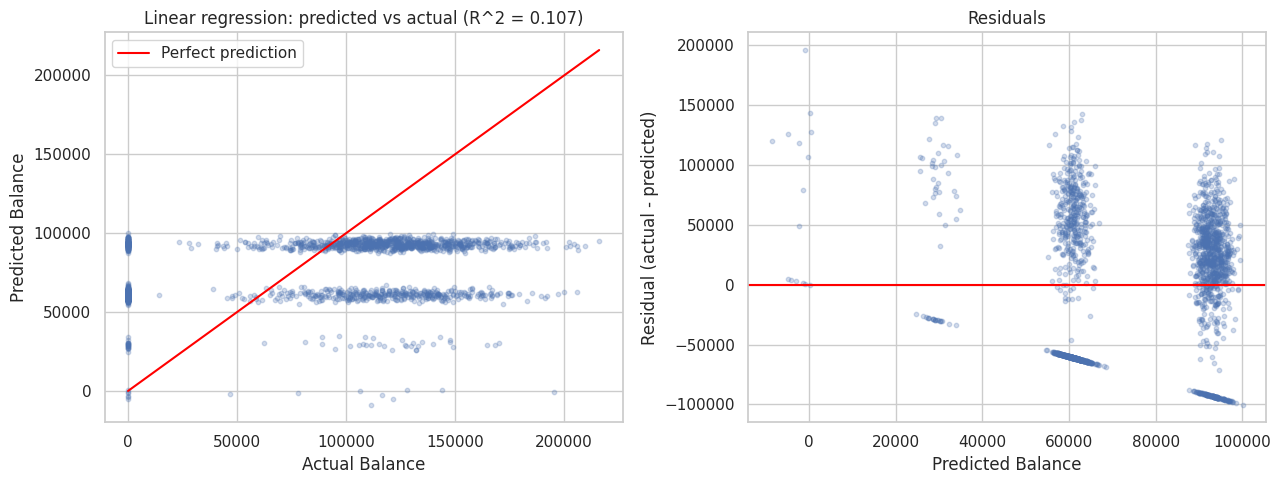


--- Interpretation ---
Test R^2 of 0.107 means the linear model explains roughly
11% of the variance in customer Balance — a weak fit.
The residual plot shows a striking horizontal band at low predicted
balances, which is the zero-balance sub-population the histogram
flagged earlier. The model cannot represent that bimodal structure
with a single linear equation. A responsible next step would be to
either (a) model zero-vs-nonzero balance separately, or (b) move
to a non-linear method. I would not deploy this regression as-is.


In [6]:
# Choosing a regression target carefully.
#
# The headline question for this dataset is "what predicts Exited?" — but
# Exited is binary (0/1), and linear regression is meant for continuous
# numeric targets. Using linear regression on a binary target is a
# *misuse* of the technique; the correct tool would be logistic regression
# (which we have not learned yet). A responsible-data-science choice is
# to pick a continuous target instead.
#
# Reasonable continuous targets in this dataset are Balance, EstimatedSalary,
# CreditScore, and Age. I'll model **Balance**, because it has the most
# economically interesting potential predictors (Age, Tenure, NumOfProducts).

target = 'Balance'
features = ['CreditScore', 'Age', 'Tenure', 'NumOfProducts',
            'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

X = df_analysis[features]
y = df_analysis[target]

# Train/test split so we get an honest estimate of fit, not just an
# in-sample number that always looks artificially good.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear regression
lin = LinearRegression().fit(X_train, y_train)
lin_train_r2 = lin.score(X_train, y_train)
lin_test_r2  = lin.score(X_test,  y_test)

print('=== Linear Regression: predicting Balance ===')
print(f'Train R^2: {lin_train_r2:.3f}')
print(f'Test  R^2: {lin_test_r2:.3f}')
print('\nCoefficients (in original units):')
for f, c in zip(features, lin.coef_):
    print(f'  {f:20s}  {c:>12.2f}')
print(f'  intercept            {lin.intercept_:>12.2f}')

# Visualize predictions vs. actuals on the test set.
y_pred = lin.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.25, s=10)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Balance')
axes[0].set_ylabel('Predicted Balance')
axes[0].set_title(f'Linear regression: predicted vs actual (R^2 = {lin_test_r2:.3f})')
axes[0].legend()

# Residuals plot — a far more honest diagnostic than just R^2.
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.25, s=10)
axes[1].axhline(0, color='red', linewidth=1.5)
axes[1].set_xlabel('Predicted Balance')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Residuals')

plt.tight_layout()
plt.show()

# Honest interpretation of the result.
print('\n--- Interpretation ---')
print(f'Test R^2 of {lin_test_r2:.3f} means the linear model explains roughly')
print(f'{lin_test_r2*100:.0f}% of the variance in customer Balance — a weak fit.')
print('The residual plot shows a striking horizontal band at low predicted')
print('balances, which is the zero-balance sub-population the histogram')
print('flagged earlier. The model cannot represent that bimodal structure')
print('with a single linear equation. A responsible next step would be to')
print('either (a) model zero-vs-nonzero balance separately, or (b) move')
print('to a non-linear method. I would not deploy this regression as-is.')

<hr>

Once you have done some machine learning analysis, answer the questions in part 4 of your week 7 journal.